## Figure 1

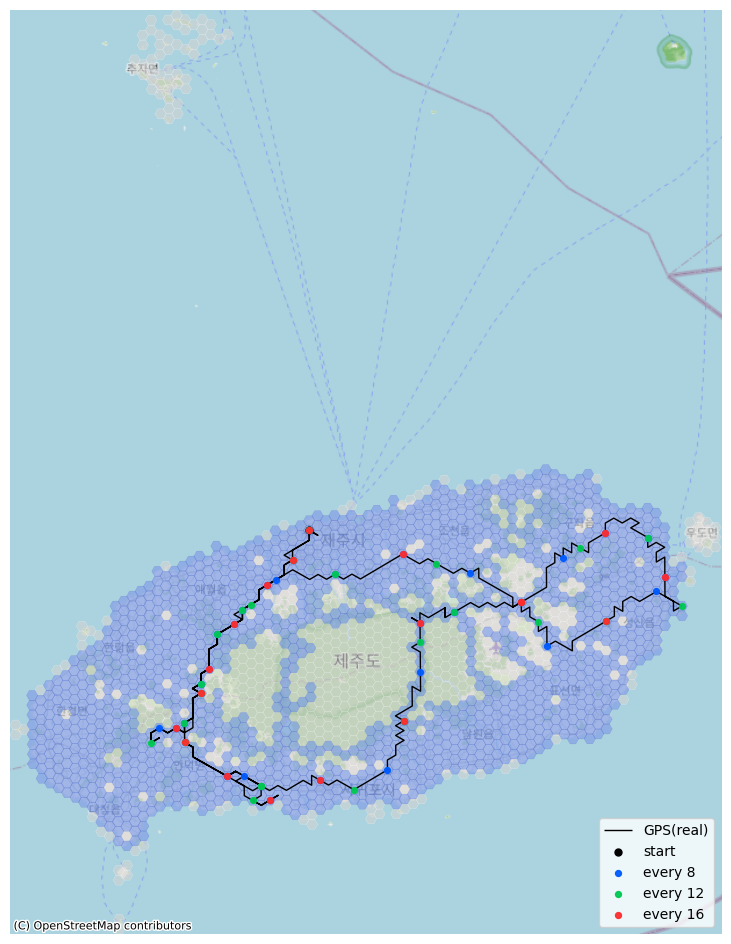

finished: ./Figure/Figure_1.png


In [1]:
# -*- coding: utf-8 -*-
import os
import ast
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from shapely.geometry import LineString
import contextily as ctx

# Levenshtein Distance (likewise with Jaccard)
BASE_HEX_PATH   = "./data/new_hexagraph/jeju_hexa_for_use.shp"
BLUE_HEX_PATH   = "./data/new_hexagraph/hexa_network_with_road.shp"
REAL_GPS_TMPL   = "./data/GPS_trajectory_for_figure/Figure_1/merged_routes_by_{k}.csv"

# Parameters
for i_person in [15]:               # Index of the selected traveler row
    OUT_DIR = "./Figure"
    os.makedirs(OUT_DIR, exist_ok=True)

    # Load data and set CRS 
    base_hex = gpd.read_file(BASE_HEX_PATH)
    blue_hex = gpd.read_file(BLUE_HEX_PATH)
    assert "new_id" in blue_hex.columns, "'new_id' column is required."

    # Change CRS to Web Mercator (EPSG:3857) for accurate distance-based sampling
    base_web = base_hex.to_crs(epsg=3857)
    blue_web = blue_hex.to_crs(epsg=3857)
    blue_idx = blue_web.set_index("new_id")

    xmin, ymin, xmax, ymax = base_web.total_bounds


    real_csv = None
    for k_try in [8, 12, 16]:
        candidate = REAL_GPS_TMPL.format(k=k_try)
        if os.path.exists(candidate):
            real_csv = candidate
            break
    if real_csv is None:
        raise FileNotFoundError("No real GPS CSV file found for k=8, 12, or 16.")

    real_df = pd.read_csv(real_csv)

    # utility functions
    def path_to_linestring(id_path, gdf_indexed):
        valid = [p for p in id_path if p in gdf_indexed.index]
        if len(valid) < 2:
            return None, None
        sub = gdf_indexed.loc[valid].copy()
        cents = sub.geometry.centroid
        line = LineString(cents.tolist())
        return line, cents

    def sample_every(cents, step):
        if cents is None or len(cents) == 0:
            return gpd.GeoSeries([], crs=3857)
        idxs = list(range(0, len(cents), step))
        return gpd.GeoSeries(cents.iloc[idxs].values, crs=3857)

    # ith person's path
    if i_person >= len(real_df):
        raise IndexError(f"i_person={i_person} exceeds the number of rows in real_df ({len(real_df)}).")

    real_path = ast.literal_eval(real_df.iloc[i_person, 1])
    real_line, real_cents = path_to_linestring(real_path, blue_idx)
    if real_line is None:
        raise ValueError("The real path does not contain enough valid hex IDs to form a LineString.")

    # visualization
    fig, ax = plt.subplots(figsize=(12, 12))
    HALO = [pe.Stroke(linewidth=4.5, foreground="white"), pe.Normal()]

    base_web.plot(ax=ax, facecolor="lightgray", edgecolor="white",
                  linewidth=0.2, alpha=0.6, zorder=1)

    blue_web.plot(ax=ax, facecolor="#2F6BFF", edgecolor="#1E40AF",
                  linewidth=0.3, alpha=0.35, zorder=2)

    gpd.GeoSeries([real_line], crs=3857).plot(
        ax=ax, color="#000000", linewidth=1.0, alpha=1.0,
        zorder=9, label="GPS(real)"
    )

    if real_cents is not None and len(real_cents) > 0:
        gpd.GeoSeries([real_cents.iloc[0]], crs=3857).plot(
            ax=ax, color="black", markersize=25, zorder=10, label="start"
        )

    pts_8  = sample_every(real_cents, 8)
    pts_12 = sample_every(real_cents, 12)
    pts_16 = sample_every(real_cents, 16)

    if len(pts_8) > 0:
        pts_8.plot(ax=ax, marker='o', markersize=18, color="#005BFF", alpha=0.95,
                   zorder=11, label="every 8")
    if len(pts_12) > 0:
        pts_12.plot(ax=ax, marker='o', markersize=18, color="#00C853", alpha=0.95,
                    zorder=12, label="every 12")
    if len(pts_16) > 0:
        pts_16.plot(ax=ax, marker='o', markersize=18, color="#FF2D2D", alpha=0.95,
                    zorder=13, label="every 16")


    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, reset_extent=False)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    ax.set_axis_off()
    plt.legend(fontsize=10, loc="lower right")

    out_png = os.path.join(OUT_DIR, "Figure_1.png")
    plt.savefig(out_png, dpi=300)
    plt.show()

    print(f"finished: {out_png}")


## Figure 6

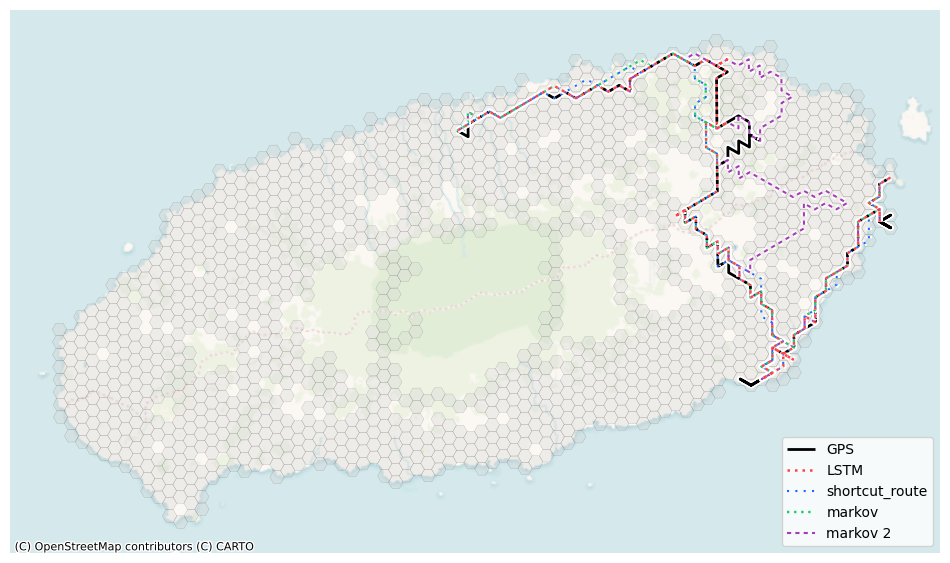

In [2]:
import numpy as np
import pandas as pd
import networkx as nx
import geopandas as gpd
import matplotlib.pyplot as plt
import torch
import ast
import re
from shapely.geometry import LineString
from shapely.affinity import translate
import contextily as ctx
import matplotlib.font_manager as fm
import matplotlib as mpl
from matplotlib.patches import Rectangle
from torch_geometric.data import Data
import os
import matplotlib.patheffects as pe
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

gdf = gpd.read_file("./data/new_hexagraph/hexa_network_with_road.shp")
gdf_web = gdf.to_crs(epsg=3857)

for l in [0]:
    for k in [12]:
        
        # LSTM
        pred_df = pd.read_csv(f'./data/GPS_trajectory_for_figure/Figure_6/LSTM_fix_{k}_by1.csv')
        pred_path = ast.literal_eval(pred_df.iloc[l, 1])
        pred_gdf = gdf.set_index('new_id').loc[pred_path].reset_index().to_crs(epsg=3857)
        pred_centroids = pred_gdf.geometry.centroid
        pred_line = LineString(pred_centroids.tolist())
        
        # GPS
        real_df = pd.read_csv(f'./data/GPS_trajectory_for_figure/Figure_6/merged_routes_by_{k}.csv')
        real_path = ast.literal_eval(real_df.iloc[l, 1])
        real_gdf = gdf.set_index('new_id').loc[real_path].reset_index().to_crs(epsg=3857)
        real_centroids = real_gdf.geometry.centroid
        real_line = LineString(real_centroids.tolist())
        real_line_offset = translate(real_line, xoff=5, yoff=5)
        
        # Shortcut
        shortcut_df = pd.read_csv(f'./data/GPS_trajectory_for_figure/Figure_6/shortcut_path_{k}.csv')
        shortcut_path = ast.literal_eval(shortcut_df.iloc[l, 1])
        shortcut_gdf = gdf.set_index('new_id').loc[shortcut_path].reset_index().to_crs(epsg=3857)
        shortcut_centroids = shortcut_gdf.geometry.centroid
        shortcut_line = LineString(shortcut_centroids.tolist())
        shortcut_line_offset = translate(shortcut_line, xoff=-5, yoff=-5)
        
        # Markov
        markov_df = pd.read_csv(f'./data/GPS_trajectory_for_figure/Figure_6/markov_route_{k}.csv')
        markov_path = ast.literal_eval(markov_df.iloc[l, 1])
        markov_path = [int(x) for x in markov_path]
        markov_gdf = gdf.set_index('new_id').loc[markov_path].reset_index().to_crs(epsg=3857)
        markov_centroids = markov_gdf.geometry.centroid
        markov_line = LineString(markov_centroids.tolist())
        markov_line_offset = translate(markov_line, xoff=-5, yoff=-5)

        # Attribute Conditioned Markov
        markov_2_df = pd.read_csv(f'./data/GPS_trajectory_for_figure/Figure_6/markov2_route_{k}.csv')
        markov_2_path = ast.literal_eval(markov_2_df.iloc[l, 1])
        markov_2_path = [int(x) for x in markov_2_path]
        markov_2_gdf = gdf.set_index('new_id').loc[markov_2_path].reset_index().to_crs(epsg=3857)
        markov_2_centroids = markov_2_gdf.geometry.centroid
        markov_2_line = LineString(markov_2_centroids.tolist())
        markov_2_line_offset = translate(markov_2_line, xoff=-5, yoff=-5)

        # Visualization
        fig, ax = plt.subplots(figsize=(12, 12))
        halo = [pe.Stroke(linewidth=4.5, foreground='white'), pe.Normal()]
        gdf_web.plot(ax=ax, color='lightgray', edgecolor='black', alpha=0.3, linewidth=0.2)
        COL_LSTM     = '#FF2D2D'  # vivid red
        COL_SHORTCUT = '#005BFF'  # vivid blue
        COL_MARKOV   = '#00C853'  # vivid green
        COL_MARKOV2 = '#9C27B0'  # vivid purple/magenta
        LS_DOT_WIDE_1 = (0, (1, 2))
        LS_DOT_WIDE_2 = (0, (1, 3))
        LS_DOT_WIDE_3 = (0, (2, 2))

        gpd.GeoSeries([real_line_offset], crs=3857).plot(
            ax=ax, color='#000000', linewidth=2.0, alpha=1.0,
            zorder=5, label='GPS', path_effects=halo
        )
        gpd.GeoSeries([pred_line], crs=3857).plot(
            ax=ax, color=COL_LSTM, linewidth=1.8, alpha=0.9,
            linestyle=LS_DOT_WIDE_1,
            zorder=9, label='LSTM', path_effects=halo
        )
        gpd.GeoSeries([shortcut_line_offset], crs=3857).plot(
            ax=ax, color=COL_SHORTCUT, linewidth=1.5, alpha=0.9,
            linestyle=LS_DOT_WIDE_2,
            zorder=8, label='shortcut_route', path_effects=halo
        )
        gpd.GeoSeries([markov_line_offset], crs=3857).plot(
            ax=ax, color=COL_MARKOV, linewidth=1.7, alpha=0.9,
            linestyle=LS_DOT_WIDE_1,
            zorder=7, label='markov', path_effects=halo
        )
        gpd.GeoSeries([markov_2_line_offset], crs=3857).plot(
            ax=ax, color=COL_MARKOV2, linewidth=1.5, alpha=0.9,
            linestyle=LS_DOT_WIDE_3,
            zorder=6, label='markov 2', path_effects=halo
        )

        # OSM
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.VoyagerNoLabels)
        plt.axis('off')
        plt.legend(fontsize=10, loc='lower right')
        plt.savefig(f'./Figure/Figure_6.png', dpi=300)
        plt.show()

## Figure 9

/tmp/ipykernel_2249622/1558535398.py:115: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10")


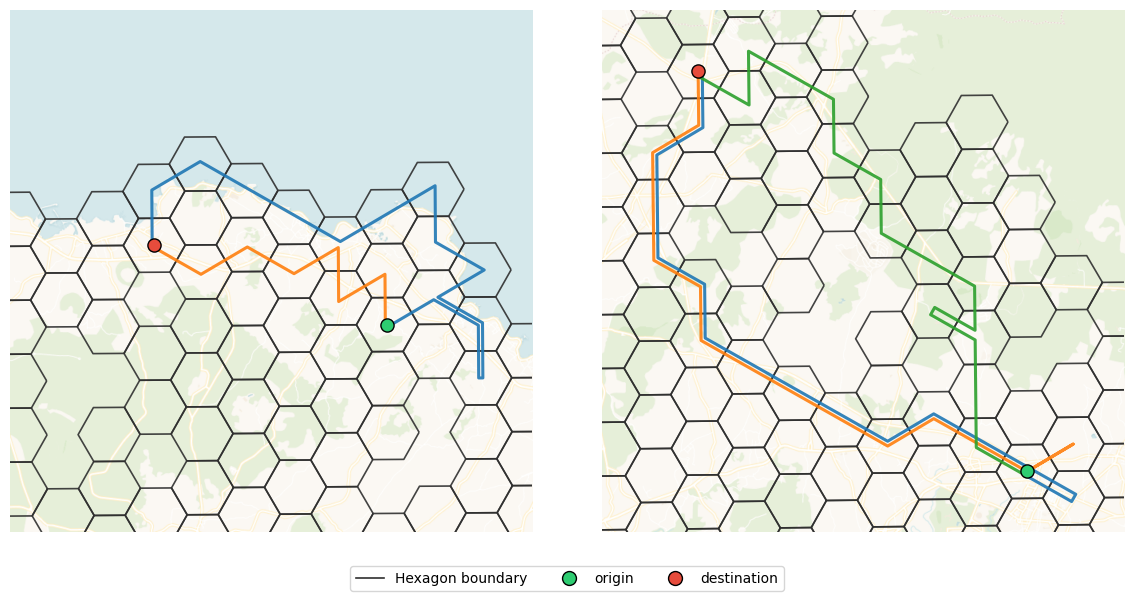

In [3]:
import os
import glob
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import contextily as ctx
from shapely.geometry import LineString, Point
from matplotlib.lines import Line2D

# trajectory path
GROUP_DIRS = [
    "./data/GPS_trajectory_for_figure/Figure_9/group_1",
    "./data/GPS_trajectory_for_figure/Figure_9/group_2",
]

# heaxagon with road
gdf = gpd.read_file("./data/new_hexagraph/hexa_network_with_road.shp")
gdf_web = gdf.to_crs(epsg=3857)

gdf_idx = gdf_web.set_index("new_id", drop=False)
centroid_by_id = {
    idx: geom.centroid
    for idx, geom in zip(gdf_idx.index, gdf_idx.geometry)
}

# utility functions
def get_centroid(pid):
    return centroid_by_id.get(int(pid), None)

def read_seq(csv_path):
    d = pd.read_csv(csv_path)

    if "path" not in d.columns or d.empty:
        return None

    return d["path"].tolist()

def seq_to_line(seq):
    pts = [get_centroid(p) for p in seq if get_centroid(p) is not None]
    return LineString(pts) if len(pts) >= 2 else None

def collect_lines_from_folder(route_dir):
    csv_files = sorted(glob.glob(os.path.join(route_dir, "*.csv")))

    lines = []

    for fpath in csv_files:
        seq = read_seq(fpath)
        if seq is None:
            continue

        line = seq_to_line(seq)
        if line is not None:
            lines.append(line)

    return lines

def bounds_from(lines, start=None, end=None):
    geoms = list(lines)

    if start is not None:
        geoms.append(Point(start.x, start.y))

    if end is not None:
        geoms.append(Point(end.x, end.y))

    if len(geoms) == 0:
        raise ValueError("No path")

    return gpd.GeoSeries(geoms, crs=gdf_web.crs).total_bounds

def get_start_end_from_lines(lines):
    if len(lines) == 0:
        return None, None

    first_line = lines[0]
    start = Point(first_line.coords[0])
    end = Point(first_line.coords[-1])

    return start, end


# group_1 / group_2 trajectory
packs = []
bounds_list = []

for group_dir in GROUP_DIRS:
    lines = collect_lines_from_folder(group_dir)
    start, end = get_start_end_from_lines(lines)

    packs.append((lines, start, end))
    bounds_list.append(bounds_from(lines, start, end))

# boundary and design
ws = [b[2] - b[0] for b in bounds_list]
hs = [b[3] - b[1] for b in bounds_list]
base = max(max(ws), max(hs), 600)

PAD = 0.15
half = base * (1 + PAD) / 2

HEX_COLOR = "#2f2f2f"
HEX_WIDTH = 1.2

START_COLOR = "#2ECC71"
END_COLOR   = "#E74C3C"

BASEMAP = ctx.providers.CartoDB.VoyagerNoLabels

# plot
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
plt.subplots_adjust(wspace=0.01)

cmap = cm.get_cmap("tab10")

for ax, pack, b in zip(axes, packs, bounds_list):

    lines, start_c, end_c = pack

    cx = (b[0] + b[2]) / 2
    cy = (b[1] + b[3]) / 2

    xmin, xmax = cx - half, cx + half
    ymin, ymax = cy - half, cy + half

    # -------- background --------
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    ctx.add_basemap(
        ax,
        source=BASEMAP,
        crs=gdf_web.crs,
        attribution=False,
        zoom='auto'
    )

    # -------- hexagon --------
    gdf_web.boundary.plot(
        ax=ax,
        edgecolor=HEX_COLOR,
        linewidth=HEX_WIDTH,
        alpha=0.9,
        zorder=2
    )

    OFFSET_STEP = 100   # meter

    n = len(lines)
    center = (n - 1) / 2

    for i, geom in enumerate(lines):

        offset_dist = (i - center) * OFFSET_STEP

        if offset_dist == 0:
            shifted = geom
        else:
            side = "left" if offset_dist > 0 else "right"
            shifted = geom.parallel_offset(
                abs(offset_dist),
                side,
                join_style=2
            )

            if shifted.geom_type == "MultiLineString":
                shifted = max(shifted.geoms, key=lambda g: g.length)

        gpd.GeoSeries([shifted], crs=gdf_web.crs).plot(
            ax=ax,
            color=cmap(i),
            linewidth=2.2,
            alpha=0.9,
            zorder=5
        )

    # -------- start / end --------
    if start_c is not None:
        ax.scatter(
            start_c.x, start_c.y,
            s=90,
            c=START_COLOR,
            edgecolors="black",
            zorder=10
        )

    if end_c is not None:
        ax.scatter(
            end_c.x, end_c.y,
            s=90,
            c=END_COLOR,
            edgecolors="black",
            zorder=10
        )

    ax.set_axis_off()

# =========================
# legend
# =========================
legend_items = [
    Line2D([0], [0], color=HEX_COLOR, lw=HEX_WIDTH, label="Hexagon boundary"),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=START_COLOR,
           markeredgecolor='black', markersize=10, label="origin"),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=END_COLOR,
           markeredgecolor='black', markersize=10, label="destination"),
]

fig.legend(
    handles=legend_items,
    loc="lower center",
    ncol=3,
    frameon=True
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig(f'./Figure/Figure_9.png', dpi=300)
plt.show()

## Figure 10

cases: 2
method        file_name  start  end
0       e013135_1_0.csv   1242  940
1       h000235_1_4.csv   1242  940


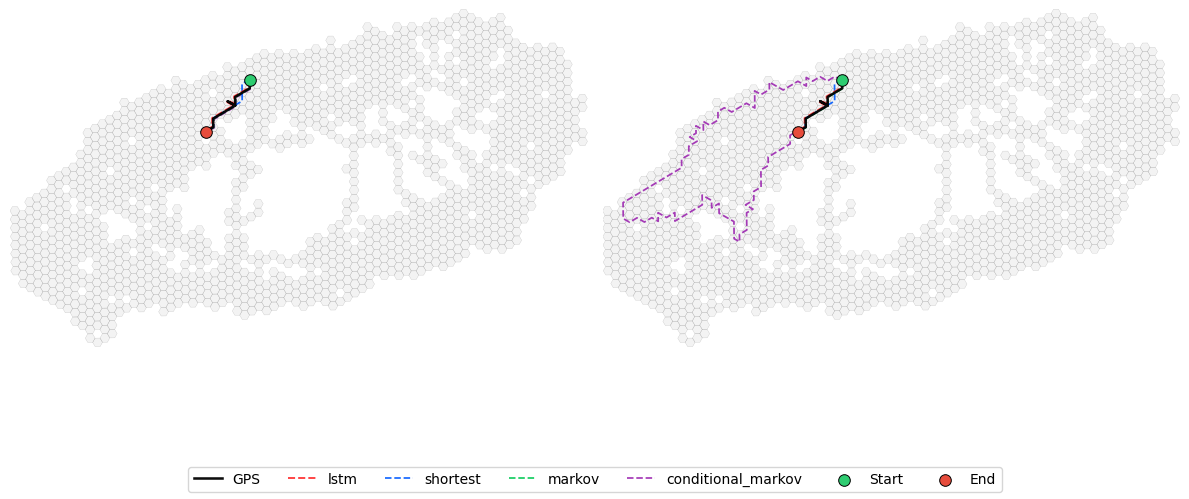

In [8]:
# -*- coding: utf-8 -*-
import os
import ast
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString
from shapely.errors import ShapelyDeprecationWarning
import warnings

warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning)

# =========================
# Paths and files
# =========================
GEN_CSV = "./data/GPS_trajectory_for_figure/Figure_10/all_multi_route_generated_routes_parallel.csv"
GPS_CSV_DIR = "./data/GPS_trajectory_for_figure/Figure_10"
SHP_PATH = "./data/new_hexagraph/hexa_network_with_road.shp"

TARGET_FILES = [
    "e013135_1_0.csv",
    "h000235_1_4.csv",
]

OUT_FIG = "./Figure/Figure_10.png"

# =========================
# Visualization settings
# =========================
COLORS = {
    "GPS": "#000000",
    "lstm": "#FF2D2D",
    "shortest": "#005BFF",
    "markov": "#00C853",
    "markov2": "#9C27B0",
}

WIDTHS = {
    "GPS": 1.6,
    "lstm": 1.2,
    "shortest": 1.1,
    "markov": 1.1,
    "markov2": 1.1,
}

LABEL_MAP = {
    "markov2": "conditional_markov"
}

LS_DASH = "--"
W_SCALE = 1.15

OFFSET_STEP_M = 100
OFFSET_METHODS = {"lstm", "shortest", "markov", "markov2"}
OFFSET_JOIN_STYLE = 2

# =========================
# Load hexagon network
# =========================
gdf = gpd.read_file(SHP_PATH)
gdf_web = gdf.to_crs(epsg=3857)

if "new_id" not in gdf_web.columns:
    raise ValueError("No 'new_id' column found.")

gdf_idx = gdf_web.set_index("new_id", drop=False)

centroid_by_id = {
    int(i): geom.centroid
    for i, geom in zip(gdf_idx["new_id"], gdf_idx.geometry)
}

XMIN, YMIN, XMAX, YMAX = gdf_web.total_bounds

# =========================
# Load generated routes
# =========================
df = pd.read_csv(GEN_CSV)

need = {"start", "end", "file_name", "generated_route", "method"}
missing = need - set(df.columns)

if missing:
    raise ValueError(f"GEN_CSV does not contain the required columns: {missing}")

# generated_route 문자열을 list로 변환
parsed_routes = []

for x in df["generated_route"]:
    if isinstance(x, list):
        parsed_routes.append(x)
    else:
        try:
            v = ast.literal_eval(x)
            parsed_routes.append(v if isinstance(v, list) else [])
        except Exception:
            parsed_routes.append([])

df["route"] = parsed_routes

sub = df[df["file_name"].isin(TARGET_FILES)].copy()

if sub.empty:
    raise RuntimeError("No generated routes found for the specified TARGET_FILES.")

pivot = (
    sub.pivot_table(
        index=["start", "end", "file_name"],
        columns="method",
        values="route",
        aggfunc="first"
    )
    .reset_index()
)

pivot["file_order"] = pivot["file_name"].apply(
    lambda x: TARGET_FILES.index(x) if x in TARGET_FILES else 999
)

pivot = (
    pivot
    .sort_values("file_order")
    .drop(columns="file_order")
    .reset_index(drop=True)
)

for m in ["shortest", "markov", "markov2", "lstm"]:
    if m not in pivot.columns:
        pivot[m] = None

# =========================
# Load GPS paths
# =========================
gps_paths = []

for file_name in pivot["file_name"]:
    fpath = os.path.join(GPS_CSV_DIR, file_name)

    if not os.path.exists(fpath):
        raise FileNotFoundError(f"GPS CSV not found: {fpath}")

    gps_df = pd.read_csv(fpath)

    if "path" not in gps_df.columns:
        raise ValueError(f"{file_name} does not contain a 'path' column.")

    gps_paths.append(gps_df["path"].dropna().astype(int).tolist())

pivot["gps"] = gps_paths

print("cases:", len(pivot))
print(pivot[["file_name", "start", "end"]])

# =========================
# Plot
# =========================
n = len(pivot)

fig, axes = plt.subplots(1, n, figsize=(6 * n, 6))

if n == 1:
    axes = [axes]

method_order = ["lstm", "shortest", "markov", "markov2"]
center = (len(method_order) - 1) / 2.0

method_offset = {
    m: (j - center) * OFFSET_STEP_M
    for j, m in enumerate(method_order)
}

for i, row in pivot.iterrows():
    ax = axes[i]

    # Base map
    gdf_web.plot(
        ax=ax,
        facecolor="lightgray",
        edgecolor="black",
        alpha=0.25,
        linewidth=0.2,
        zorder=1
    )

    ax.set_xlim(XMIN, XMAX)
    ax.set_ylim(YMIN, YMAX)
    ax.set_axis_off()

    # =========================
    # GPS line
    # =========================
    gps = row["gps"] if isinstance(row["gps"], list) else []

    gps_pts = []

    for p in gps:
        try:
            pid = int(p)
        except Exception:
            continue

        c = centroid_by_id.get(pid)

        if c is not None:
            gps_pts.append(c)

    gps_line = LineString(gps_pts) if len(gps_pts) >= 2 else None

    if gps_line is not None:
        ax.plot(
            *gps_line.xy,
            color=COLORS["GPS"],
            linewidth=WIDTHS["GPS"] * W_SCALE,
            linestyle="-",
            alpha=0.95,
            zorder=10,
            label="GPS"
        )

    # =========================
    # Generated routes
    # =========================
    for z, key in zip([9, 8, 7, 6], method_order):
        route = row.get(key)

        if not isinstance(route, list) or len(route) < 2:
            continue

        pts = []

        for p in route:
            try:
                pid = int(p)
            except Exception:
                continue

            c = centroid_by_id.get(pid)

            if c is not None:
                pts.append(c)

        if len(pts) < 2:
            continue

        line = LineString(pts)

        # Offset line
        if key in OFFSET_METHODS:
            offset_dist_m = method_offset.get(key, 0.0)

            if abs(offset_dist_m) > 1e-9:
                try:
                    side = "left" if offset_dist_m > 0 else "right"

                    shifted = line.parallel_offset(
                        abs(offset_dist_m),
                        side=side,
                        join_style=OFFSET_JOIN_STYLE
                    )

                    if shifted is not None:
                        if shifted.geom_type == "MultiLineString":
                            shifted = max(
                                list(shifted.geoms),
                                key=lambda g: g.length,
                                default=line
                            )

                        line = shifted

                except Exception:
                    pass

        label = LABEL_MAP.get(key, key)

        ax.plot(
            *line.xy,
            color=COLORS[key],
            linewidth=WIDTHS[key] * W_SCALE,
            linestyle=LS_DASH,
            alpha=0.9,
            zorder=z,
            label=label
        )

    # =========================
    # Start / End points
    # =========================
    if isinstance(gps, list) and len(gps) >= 2:
        sp = centroid_by_id.get(int(gps[0]))
        ep = centroid_by_id.get(int(gps[-1]))
    else:
        sp = centroid_by_id.get(int(row["start"]))
        ep = centroid_by_id.get(int(row["end"]))

    if sp is not None:
        ax.scatter(
            [sp.x], [sp.y],
            s=70,
            c="#2ECC71",
            edgecolors="black",
            linewidths=0.7,
            zorder=30,
            label="Start"
        )

    if ep is not None:
        ax.scatter(
            [ep.x], [ep.y],
            s=70,
            c="#E74C3C",
            edgecolors="black",
            linewidths=0.7,
            zorder=30,
            label="End"
        )

# =========================
# Legend
# =========================
handles, labels = axes[0].get_legend_handles_labels()

seen = set()
uh, ul = [], []

for h, l in zip(handles, labels):
    if l and l not in seen:
        uh.append(h)
        ul.append(l)
        seen.add(l)

fig.legend(
    uh,
    ul,
    loc="lower center",
    ncol=7,
    fontsize=10,
    frameon=True
)

plt.tight_layout(rect=[0, 0.06, 1, 1])

# =========================
# Save and show
# =========================
os.makedirs(os.path.dirname(OUT_FIG), exist_ok=True)

plt.savefig(
    OUT_FIG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Figure 11

cases: 2
['h000108_3_0.csv', 'h004703_6_0.csv']


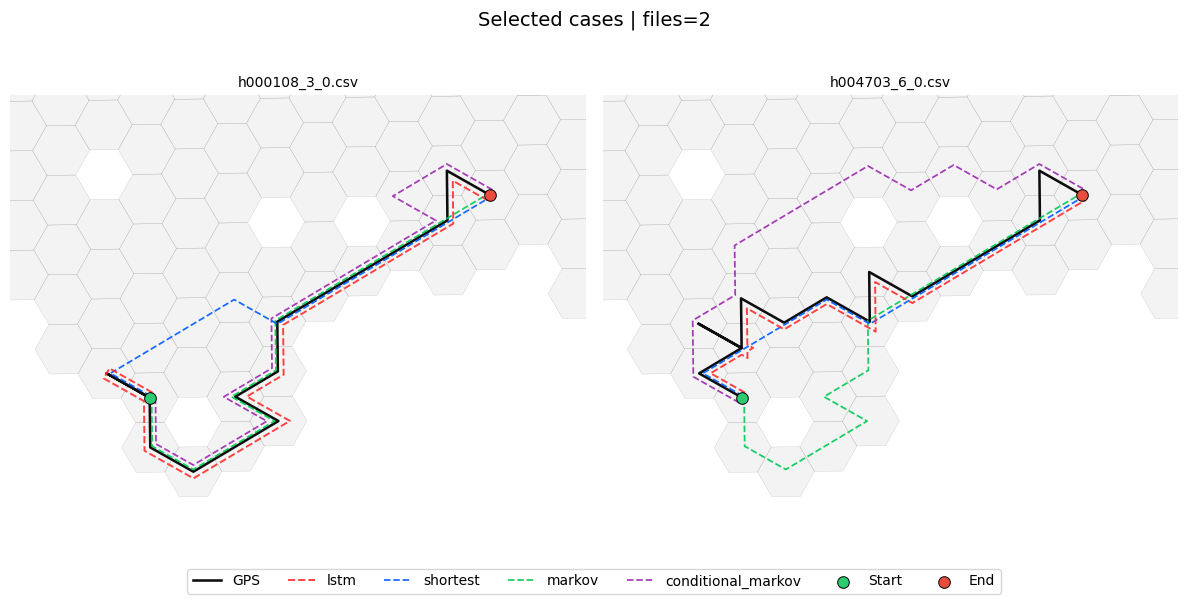

In [11]:
# -*- coding: utf-8 -*-
import os
import ast
import warnings
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import LineString
from shapely.errors import ShapelyDeprecationWarning

warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning)

# =========================
# Paths and files
# =========================
GEN_CSV = "./data/GPS_trajectory_for_figure/Figure_11/all_multi_route_generated_routes_parallel.csv"
GPS_TRAJ_DIR = "./data/GPS_trajectory_for_figure/Figure_11"
SHP_PATH = "./data/new_hexagraph/hexa_network_with_road.shp"

TARGET_FILES = [
    "h000108_3_0.csv",
    "h004703_6_0.csv",
]

OUT_FIG = "./Figure/Figure_11.png"

# =========================
# Visualization settings
# =========================
COLORS = {
    "GPS": "#000000",
    "lstm": "#FF2D2D",
    "shortest": "#005BFF",
    "markov": "#00C853",
    "markov2": "#9C27B0",
}

WIDTHS = {
    "GPS": 1.6,
    "lstm": 1.2,
    "shortest": 1.1,
    "markov": 1.1,
    "markov2": 1.1,
}

LABEL_MAP = {
    "markov2": "conditional_markov"
}

LS_DASH = "--"
W_SCALE = 1.15

OFFSET_STEP_M = 100
OFFSET_JOIN_STYLE = 2

method_order = ["lstm", "shortest", "markov", "markov2"]
center = (len(method_order) - 1) / 2.0

method_offset = {
    m: (j - center) * OFFSET_STEP_M
    for j, m in enumerate(method_order)
}

# =========================
# Load hexagon network
# =========================
gdf = gpd.read_file(SHP_PATH)
gdf_web = gdf.to_crs(epsg=3857)

if "new_id" not in gdf_web.columns:
    raise ValueError("No 'new_id' column found.")

gdf_idx = gdf_web.set_index("new_id", drop=False)

centroid_by_id = {
    int(i): geom.centroid
    for i, geom in zip(gdf_idx["new_id"], gdf_idx.geometry)
}

# =========================
# Load generated routes
# =========================
df = pd.read_csv(GEN_CSV)

need = {"start", "end", "k", "file_name", "generated_route", "method"}
missing = need - set(df.columns)

if missing:
    raise ValueError(f"GEN_CSV does not contain the required columns: {missing}")

# generated_route 문자열을 list로 변환
parsed_routes = []

for x in df["generated_route"]:
    if isinstance(x, list):
        parsed_routes.append(x)
    else:
        try:
            v = ast.literal_eval(x)
            parsed_routes.append(v if isinstance(v, list) else [])
        except Exception:
            parsed_routes.append([])

df["route"] = parsed_routes

sub = df[df["file_name"].isin(TARGET_FILES)].copy()

if sub.empty:
    raise RuntimeError("No generated routes found for the specified TARGET_FILES.")

pivot = (
    sub.pivot_table(
        index="file_name",
        columns="method",
        values="route",
        aggfunc="first"
    )
    .reset_index()
)

pivot["file_order"] = pivot["file_name"].apply(
    lambda x: TARGET_FILES.index(x) if x in TARGET_FILES else 999
)

pivot = (
    pivot
    .sort_values("file_order")
    .drop(columns="file_order")
    .reset_index(drop=True)
)

for m in ["shortest", "markov", "markov2", "lstm"]:
    if m not in pivot.columns:
        pivot[m] = None

# =========================
# Load GPS trajectories
# =========================
gps_paths = []

for file_name in pivot["file_name"]:
    fpath = os.path.join(GPS_TRAJ_DIR, file_name)

    if not os.path.exists(fpath):
        raise FileNotFoundError(f"GPS CSV not found: {fpath}")

    gps_df = pd.read_csv(fpath)

    if "path" not in gps_df.columns:
        raise ValueError(f"{file_name} does not contain a 'path' column.")

    gps_paths.append(gps_df["path"].dropna().astype(int).tolist())

pivot["gps"] = gps_paths

print("cases:", len(pivot))
print(pivot["file_name"].tolist())

# =========================
# Compute zoom bounds
# =========================
geoms = []

for _, row in pivot.iterrows():
    # GPS line
    gps = row["gps"] if isinstance(row["gps"], list) else []
    pts = []

    for p in gps:
        try:
            pid = int(p)
        except Exception:
            continue

        c = centroid_by_id.get(pid)

        if c is not None:
            pts.append(c)

    if len(pts) >= 2:
        geoms.append(LineString(pts))

    # Generated route lines
    for key in method_order:
        route = row.get(key)

        if not isinstance(route, list) or len(route) < 2:
            continue

        pts = []

        for p in route:
            try:
                pid = int(p)
            except Exception:
                continue

            c = centroid_by_id.get(pid)

            if c is not None:
                pts.append(c)

        if len(pts) >= 2:
            geoms.append(LineString(pts))

if geoms:
    zoom_gs = gpd.GeoSeries(geoms, crs=gdf_web.crs)
    XMIN, YMIN, XMAX, YMAX = zoom_gs.total_bounds

    w = max(XMAX - XMIN, 1e-9)
    h = max(YMAX - YMIN, 1e-9)

    pad_x = max(w * 0.25, 300.0)
    pad_y = max(h * 0.25, 300.0)

    XMIN -= pad_x
    XMAX += pad_x
    YMIN -= pad_y
    YMAX += pad_y

else:
    XMIN, YMIN, XMAX, YMAX = gdf_web.total_bounds

# =========================
# Plot
# =========================
n = len(pivot)

if n <= 0:
    raise RuntimeError("No cases to plot.")

fig, axes = plt.subplots(1, n, figsize=(6 * n, 6))

if n == 1:
    axes = [axes]

for i, row in pivot.iterrows():
    ax = axes[i]

    # Base map
    gdf_web.plot(
        ax=ax,
        facecolor="lightgray",
        edgecolor="black",
        alpha=0.25,
        linewidth=0.2,
        zorder=1
    )

    ax.set_xlim(XMIN, XMAX)
    ax.set_ylim(YMIN, YMAX)
    ax.set_axis_off()

    # =========================
    # GPS line
    # =========================
    gps = row["gps"] if isinstance(row["gps"], list) else []
    gps_pts = []

    for p in gps:
        try:
            pid = int(p)
        except Exception:
            continue

        c = centroid_by_id.get(pid)

        if c is not None:
            gps_pts.append(c)

    gps_line = LineString(gps_pts) if len(gps_pts) >= 2 else None

    if gps_line is not None:
        ax.plot(
            *gps_line.xy,
            color=COLORS["GPS"],
            linewidth=WIDTHS["GPS"] * W_SCALE,
            linestyle="-",
            alpha=0.95,
            zorder=2,
            label="GPS"
        )

    # =========================
    # Generated route lines
    # =========================
    for z, key in zip([9, 8, 7, 6], method_order):
        route = row.get(key)

        if not isinstance(route, list) or len(route) < 2:
            continue

        pts = []

        for p in route:
            try:
                pid = int(p)
            except Exception:
                continue

            c = centroid_by_id.get(pid)

            if c is not None:
                pts.append(c)

        if len(pts) < 2:
            continue

        line = LineString(pts)

        # Offset
        offset_dist_m = method_offset.get(key, 0.0)

        if abs(offset_dist_m) > 1e-9:
            try:
                side = "left" if offset_dist_m > 0 else "right"

                shifted = line.parallel_offset(
                    abs(offset_dist_m),
                    side=side,
                    join_style=OFFSET_JOIN_STYLE
                )

                if shifted is not None:
                    if shifted.geom_type == "MultiLineString":
                        shifted = max(
                            list(shifted.geoms),
                            key=lambda g: g.length,
                            default=line
                        )

                    line = shifted

            except Exception:
                pass

        label = LABEL_MAP.get(key, key)

        ax.plot(
            *line.xy,
            color=COLORS[key],
            linewidth=WIDTHS[key] * W_SCALE,
            linestyle=LS_DASH,
            alpha=0.9,
            zorder=z,
            label=label
        )

    # =========================
    # Start / End points
    # =========================
    if isinstance(gps, list) and len(gps) >= 2:
        sp = centroid_by_id.get(int(gps[0]))
        ep = centroid_by_id.get(int(gps[-1]))

        if sp is not None:
            ax.scatter(
                [sp.x], [sp.y],
                s=70,
                c="#2ECC71",
                edgecolors="black",
                linewidths=0.7,
                zorder=30,
                label="Start"
            )

        if ep is not None:
            ax.scatter(
                [ep.x], [ep.y],
                s=70,
                c="#E74C3C",
                edgecolors="black",
                linewidths=0.7,
                zorder=30,
                label="End"
            )

    ax.set_title(row["file_name"], fontsize=10)

# =========================
# Legend
# =========================
handles, labels = axes[0].get_legend_handles_labels()

seen = set()
uh, ul = [], []

for h, l in zip(handles, labels):
    if l and l not in seen:
        uh.append(h)
        ul.append(l)
        seen.add(l)

fig.legend(
    uh,
    ul,
    loc="lower center",
    ncol=7,
    fontsize=10,
    frameon=True
)

plt.suptitle(
    f"Selected cases | files={n}",
    fontsize=14
)

plt.tight_layout(rect=[0, 0.06, 1, 0.92])

# =========================
# Save and show
# =========================
os.makedirs(os.path.dirname(OUT_FIG), exist_ok=True)

plt.savefig(
    OUT_FIG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()